In [ ]:
!pip install botorch

In [ ]:
# Bayesian Optimization for Pareto Front Discovery
# Using botorch + GPyTorch with ARDSE-RBF kernels
# Support for switching between initial designs (support_points, random_points)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import re
import warnings
warnings.filterwarnings('ignore')

import torch
import gpytorch
import botorch
from botorch.models import SingleTaskGP
from botorch.models.kernels.categorical import CategoricalKernel
from botorch.acquisition.multi_objective.monte_carlo import qExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.utils.multi_objective.pareto import is_non_dominated

DIR='/content/drive'
HOME = os.path.join(DIR, 'MyDrive')
from google.colab import drive
drive.mount(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Using device: cuda

LOADING DATA

✓ Using SUPPORT POINTS as initial design (n=20)
  Pool size: 4495
  Initial design size: 20
  Initial Pareto size: 4

BAYESIAN OPTIMIZATION

Objective formulation (CORRECTED):
  Minimize: Formation Energy (lower = more stable)
  Maximize: Bulk Modulus (higher = stiffer)
  → Multi-objective: y = [Energy, -Modulus] for minimization

--- Iteration 1/20 ---
  Current data points: 20
  Current Pareto size: 5
  Training Gaussian Process models...
  Avg Pareto uncertainty: 6.7483
  Selecting next candidate from 4495 candidates...
  Suggestion 1/2:
    Pool index: 2944
    Energy: -22.49 eV (target: minimize)
    Modulus: 134.91 GPa (target: maximize)
    EHVI score: 3.8662
  Suggestion 2/2:
    Pool index: 4036
    Energy: -33.63 eV (target: minimize)
    Modulus: 123.68 GPa (target: maximize)
    EHVI score: 3.8225

--- Iteration 2/20 ---
  Current data points: 22
  Current Pareto size: 7
  Training Gaussian Process models...
  Avg Pareto uncertainty: 1.5355

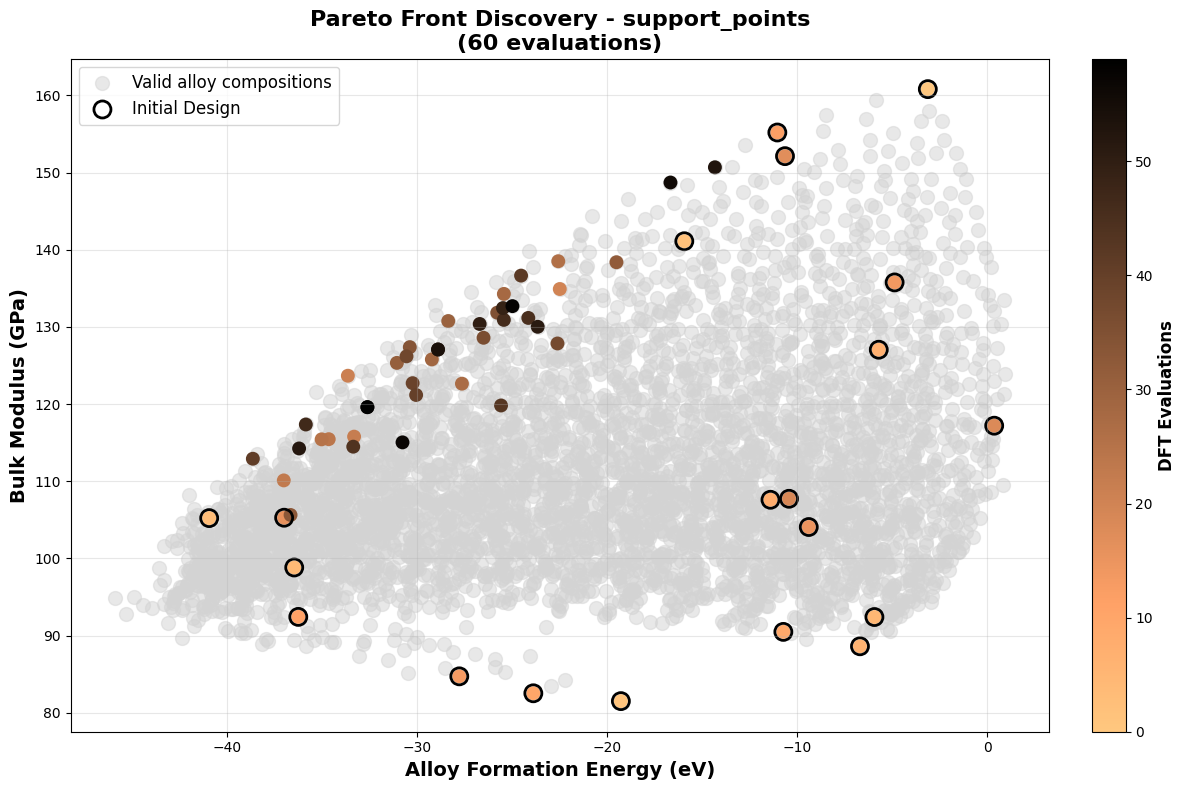

✓ Saved composition_space_support_points.png


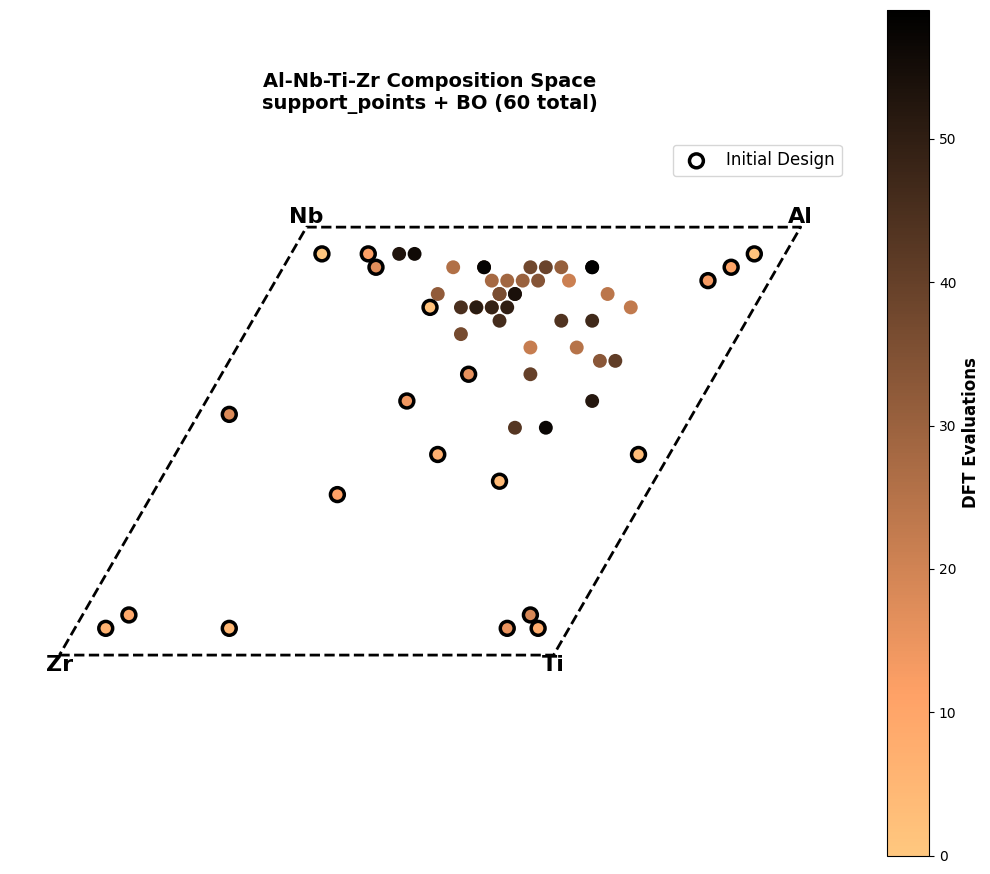


PARETO FRONT COVERAGE ANALYSIS

True Pareto Front (from full pool):
  Size: 47
  Energy range: [-45.86, -3.14] eV
  Modulus range: [94.84, 160.82] GPa

BO Pareto Front Coverage:
  BO found: 9 out of 47 true Pareto points
  Coverage: 19.1%

  BO Pareto points (discovered): 18
  Energy range covered: [-40.92, -3.14] eV
  Modulus range covered: [105.23, 160.82] GPa

Pareto Front Quality (Hypervolume Proxy):
  True Pareto HV: 2819.03 (eV × GPa)
  BO Pareto HV: 2100.53 (eV × GPa)
  Ratio (BO/True): 74.5%

SUMMARY STATISTICS

Initial design: support_points
Total evaluations: 60
Initial points: 20
BO-added points: 40

Final Pareto front:
  Size: 18
  Energy range: [-40.92, -3.14] eV
  Modulus range: [105.23, 160.82] GPa

✓ All plots and results saved!

CORRECTED FORMULATION
Multi-objective: y = [Energy, -Modulus]
  → Minimizes Formation Energy (stable alloys) ✓
  → Maximizes Bulk Modulus (stiff alloys) ✓
  Pool size: 4495
  Initial design size: 20
  Initial Pareto size: 4

BAYESIAN OPTIMIZAT

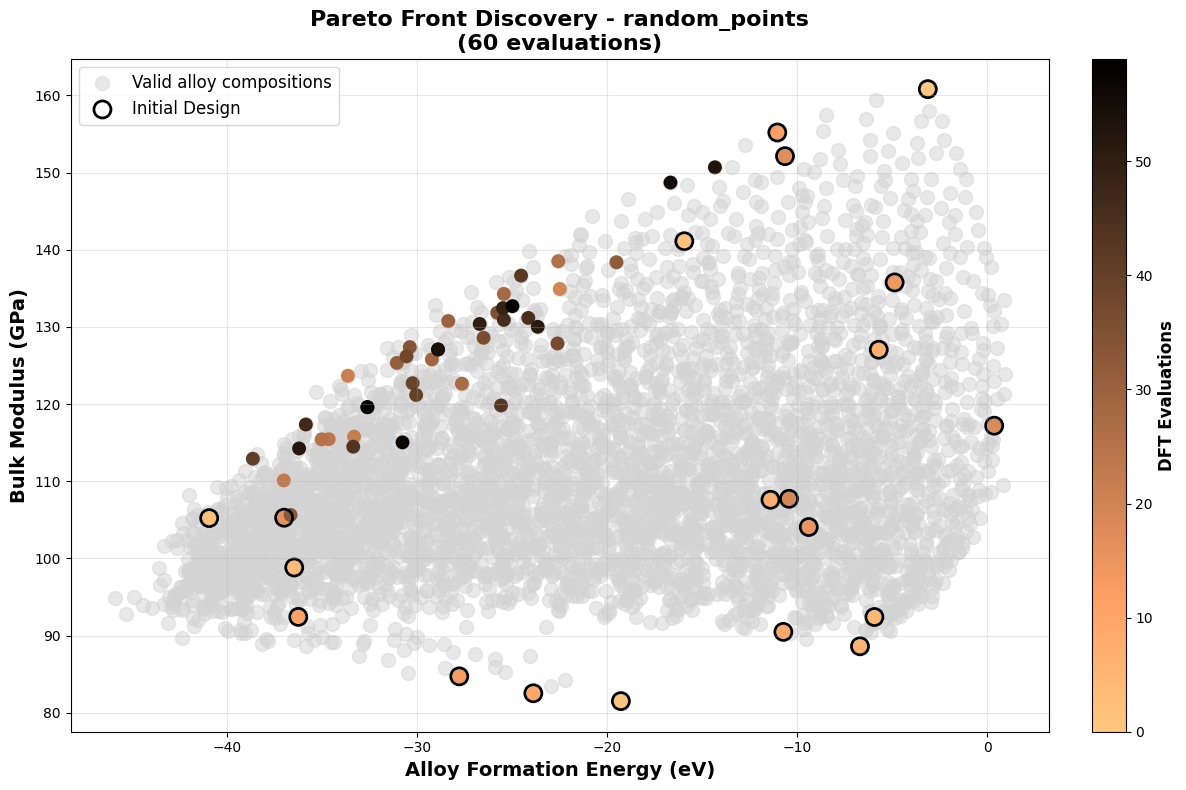

✓ Saved composition_space_random_points.png


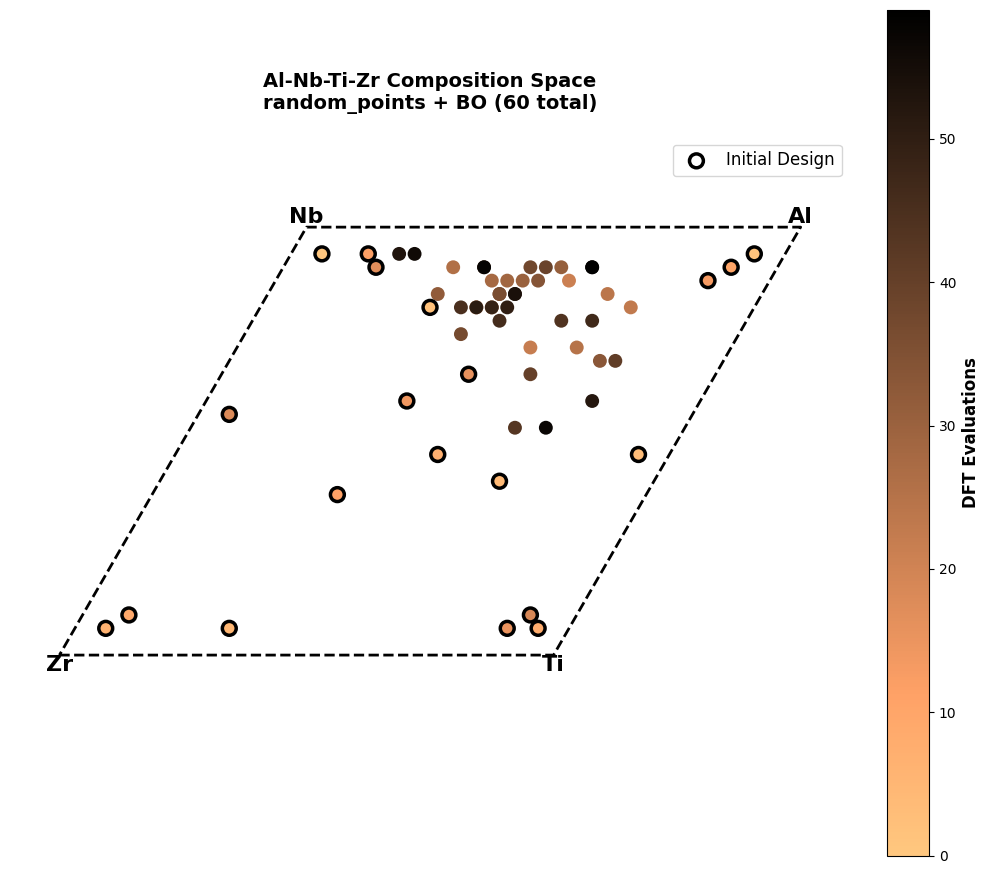


PARETO FRONT COVERAGE ANALYSIS

True Pareto Front (from full pool):
  Size: 47
  Energy range: [-45.86, -3.14] eV
  Modulus range: [94.84, 160.82] GPa

BO Pareto Front Coverage:
  BO found: 9 out of 47 true Pareto points
  Coverage: 19.1%

  BO Pareto points (discovered): 18
  Energy range covered: [-40.92, -3.14] eV
  Modulus range covered: [105.23, 160.82] GPa

Pareto Front Quality (Hypervolume Proxy):
  True Pareto HV: 2819.03 (eV × GPa)
  BO Pareto HV: 2100.53 (eV × GPa)
  Ratio (BO/True): 74.5%

SUMMARY STATISTICS

Initial design: random_points
Total evaluations: 60
Initial points: 20
BO-added points: 40

Final Pareto front:
  Size: 18
  Energy range: [-40.92, -3.14] eV
  Modulus range: [105.23, 160.82] GPa

✓ All plots and results saved!

CORRECTED FORMULATION
Multi-objective: y = [Energy, -Modulus]
  → Minimizes Formation Energy (stable alloys) ✓
  → Maximizes Bulk Modulus (stiff alloys) ✓


In [ ]:


# ============================================================================
# CONFIGURATION
# ============================================================================

# Choose initial design: 'support_points' or 'random_points'
INITIAL_DESIGN = 'support_points'  # Change to 'random_points' for separate run

# BO settings
N_ITERATIONS = 20
N_CANDIDATES_PER_ITER = 50
REFERENCE_POINT = torch.tensor([1.0, 81.0])  # (E_worst, K_worst) - actual data bounds

N_SUGGESTIONS_PER_ITER = 2  # Number of candidates to suggest per iteration

# GPyTorch settings
TRAIN_ITER = 100
LEARNING_RATE = 0.1

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============================================================================
# DATA LOADING
# ============================================================================

print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load full dataset
full_data = pd.read_csv(os.path.join(HOME, "Analyze4RHEA","alloy_perc.csv"))
comp_cols = ['Zr_Percent', 'Ti_Percent', 'Nb_Percent', 'Al_Percent']

# Load initial design
if INITIAL_DESIGN == 'support_points':
    initial_data = pd.read_csv(os.path.join(HOME, "Analyze4RHEA",'support_points__20.csv'))
    print(f"\n✓ Using SUPPORT POINTS as initial design (n={len(initial_data)})")
elif INITIAL_DESIGN == 'random_points':
    initial_data = pd.read_csv(os.path.join(HOME, "Analyze4RHEA",'random_points__20.csv'))
    print(f"\n✓ Using RANDOM POINTS as initial design (n={len(initial_data)})")
else:
    raise ValueError(f"Unknown initial design: {INITIAL_DESIGN}")

for INITIAL_DESIGN in ['support_points', 'random_points']:
    # Extract compositions and properties
    comp_pool = full_data[comp_cols].values.astype(np.float32)
    energy_pool = full_data['Formation_Energy'].values.astype(np.float32)
    moduli_pool = full_data['Bulk_Modulus'].values.astype(np.float32)

    initial_comp = initial_data[comp_cols].values.astype(np.float32)
    initial_energy = initial_data['Formation_Energy'].values.astype(np.float32)
    initial_moduli = initial_data['Bulk_Modulus'].values.astype(np.float32)

    print(f"  Pool size: {len(comp_pool)}")
    print(f"  Initial design size: {len(initial_comp)}")
    print(f"  Initial Pareto size: {len(np.where(is_non_dominated(torch.tensor(np.column_stack([initial_energy, -initial_moduli]))))[0])}")

    # ============================================================================
    # CUSTOM GPYTORCH MODEL WITH ARDSE-RBF KERNEL
    # ============================================================================

    class ARDSEKernel(gpytorch.kernels.Kernel):
        """
        Automatic Relevance Determination Squared Exponential (ARDSE) kernel
        (i.e., RBF with learned per-dimension length scales)
        """
        is_stationary = True
        has_lengthscale = True

        def __init__(self, ard_num_dims=None, **kwargs):
            super().__init__(**kwargs)
            self.ard_num_dims = ard_num_dims

            if ard_num_dims is None:
                raise ValueError("Must provide ard_num_dims")

            # Initialize length scale for each dimension
            self.register_parameter(
                'raw_lengthscale',
                torch.nn.Parameter(torch.zeros(1, ard_num_dims))
            )

        @property
        def lengthscale(self):
            return torch.exp(self.raw_lengthscale)

        @lengthscale.setter
        def lengthscale(self, value):
            with torch.no_grad():
                self.raw_lengthscale.copy_(torch.log(value))

        def forward(self, x1, x2, diag=False, **kwargs):
            # Compute scaled distances
            x1_scaled = x1 / self.lengthscale
            x2_scaled = x2 / self.lengthscale

            # Compute RBF kernel
            if diag:
                return torch.ones(x1.shape[0], device=x1.device, dtype=x1.dtype)
            else:
                distance = torch.cdist(x1_scaled, x2_scaled, p=2)
                return torch.exp(-0.5 * distance ** 2)


    class ARDSEGPModel(gpytorch.models.ExactGP):
        """GPyTorch model with ARDSE-RBF kernel"""

        def __init__(self, train_x, train_y, likelihood, ard_dims):
            super().__init__(train_x, train_y, likelihood)

            self.mean_module = gpytorch.means.ConstantMean()

            # ARDSE kernel with length scale per dimension
            self.covar_module = gpytorch.kernels.ScaleKernel(
                ARDSEKernel(ard_num_dims=ard_dims)
            )

        def forward(self, x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

    def train_gp_model(train_x, train_y, likelihood, ard_dims, n_iter=TRAIN_ITER):
        """Train GPyTorch model with ARDSE kernel"""

        # Store normalization stats
        x_mean = train_x.mean(dim=0)
        x_std = train_x.std(dim=0) + 1e-6
        y_mean = train_y.mean()
        y_std = train_y.std() + 1e-6

        # Normalize data
        train_x_norm = (train_x - x_mean) / x_std
        train_y_norm = (train_y - y_mean) / y_std

        model = ARDSEGPModel(train_x_norm, train_y_norm, likelihood, ard_dims)
        model.to(DEVICE)

        model.train()
        likelihood.train()

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

        for i in range(n_iter):
            optimizer.zero_grad()
            output = model(train_x_norm)
            loss = -mll(output, train_y_norm)
            loss.backward()
            optimizer.step()

        model.eval()
        likelihood.eval()

        return model, likelihood, x_mean, x_std, y_mean, y_std



    # ============================================================================
    # BAYESIAN OPTIMIZATION LOOP
    # ============================================================================

    print("\n" + "="*80)
    print("BAYESIAN OPTIMIZATION")
    print("="*80)
    print("\nObjective formulation (CORRECTED):")
    print("  Minimize: Formation Energy (lower = more stable)")
    print("  Maximize: Bulk Modulus (higher = stiffer)")
    print("  → Multi-objective: y = [Energy, -Modulus] for minimization")

    # Initialize data
    current_comp = torch.tensor(initial_comp, device=DEVICE, dtype=torch.float32)
    current_energy = torch.tensor(initial_energy, device=DEVICE, dtype=torch.float32)
    current_moduli = torch.tensor(initial_moduli, device=DEVICE, dtype=torch.float32)

    # Track evaluations
    eval_count = np.arange(len(initial_comp), dtype=np.int32)  # [0, 1, ..., n_init-1]
    dft_eval_history = [eval_count.copy()]

    # Convert pool to tensor
    comp_pool_tensor = torch.tensor(comp_pool, device=DEVICE, dtype=torch.float32)
    energy_pool_tensor = torch.tensor(energy_pool, device=DEVICE, dtype=torch.float32)
    moduli_pool_tensor = torch.tensor(moduli_pool, device=DEVICE, dtype=torch.float32)

    # *** CORRECTED: Multi-objective formulation ***
    # Minimize energy, Maximize modulus → [energy, -modulus] for all-minimization
    y_current = torch.stack([-current_energy, current_moduli], dim=1)
    #                        ^^^^^^^^^^^^^^  ^^^^^^^^^^^^^^
    #                        NOT negated     Negated (to convert max→min)

    pareto_sizes = []
    uncertainties = []

    for iteration in range(N_ITERATIONS):
        print(f"\n--- Iteration {iteration + 1}/{N_ITERATIONS} ---")
        print(f"  Current data points: {len(current_comp)}")

        # Identify current Pareto front
        pareto_mask = is_non_dominated(y_current)
        pareto_idx = np.where(pareto_mask.cpu().numpy())[0]
        pareto_sizes.append(len(pareto_idx))

        print(f"  Current Pareto size: {len(pareto_idx)}")

        # Compute average uncertainty on Pareto front (for convergence tracking)
        if len(pareto_idx) > 0:
            # Train GPs
            print(f"  Training Gaussian Process models...")

            likelihood_e = gpytorch.likelihoods.GaussianLikelihood()
            model_e, likelihood_e, xe_mean, xe_std, ye_mean, ye_std = train_gp_model(
                current_comp, current_energy, likelihood_e, ard_dims=current_comp.shape[1]
            )

            likelihood_k = gpytorch.likelihoods.GaussianLikelihood()
            model_k, likelihood_k, xk_mean, xk_std, yk_mean, yk_std = train_gp_model(
                current_comp, current_moduli, likelihood_k, ard_dims=current_comp.shape[1]
            )

            # Predict on Pareto front
            with torch.no_grad():
                pareto_x = current_comp[pareto_idx]
                pareto_x_norm = (pareto_x - xe_mean) / xe_std

                dist_e = likelihood_e(model_e(pareto_x_norm))
                std_e = dist_e.stddev.cpu().numpy() * ye_std.cpu().numpy()

                pareto_x_norm_k = (pareto_x - xk_mean) / xk_std
                dist_k = likelihood_k(model_k(pareto_x_norm_k))
                std_k = dist_k.stddev.cpu().numpy() * yk_std.cpu().numpy()

                avg_uncertainty = (std_e + std_k).mean()

            uncertainties.append(avg_uncertainty)
            print(f"  Avg Pareto uncertainty: {avg_uncertainty:.4f}")

        # Select next candidate using EHVI
        print(f"  Selecting next candidate from {len(comp_pool)} candidates...")

        np.random.seed(iteration)
        candidate_indices = np.random.choice(len(comp_pool), min(N_CANDIDATES_PER_ITER, len(comp_pool)), replace=False)
        candidates = comp_pool_tensor[candidate_indices]

        # Compute EHVI for candidates (WORK IN NORMALIZED SPACE)
        with torch.no_grad():
            candidates_norm_e = (candidates - xe_mean) / xe_std
            candidates_norm_k = (candidates - xk_mean) / xk_std

            dist_e_cand = likelihood_e(model_e(candidates_norm_e))
            pred_e_norm = dist_e_cand.mean
            std_e_cand = dist_e_cand.stddev

            dist_k_cand = likelihood_k(model_k(candidates_norm_k))
            pred_k_norm = dist_k_cand.mean
            std_k_cand = dist_k_cand.stddev

            # Normalize reference point to same scale as normalized predictions
            ref_e, ref_k = REFERENCE_POINT[0].item(), REFERENCE_POINT[1].item()
            ref_e_norm = (ref_e - ye_mean) / ye_std
            ref_k_norm = (ref_k - yk_mean) / yk_std

            # Improvement terms (IN NORMALIZED SPACE)
            e_improvement = torch.clamp(ref_e_norm - pred_e_norm, min=0)
            k_improvement = torch.clamp(pred_k_norm - ref_k_norm, min=0)

            # EHVI = (ΔE × ΔK) + λ × (σ_E + σ_K)
            improvement_term = e_improvement * k_improvement
            exploration_term = 0.5 * (std_e_cand + std_k_cand)
            ehvi = improvement_term + exploration_term




        # Select top N_SUGGESTIONS_PER_ITER candidates
        ehvi_scores = ehvi.cpu().numpy()
        top_indices = np.argsort(ehvi_scores)[-N_SUGGESTIONS_PER_ITER:][::-1]  # Sort descending

        for idx, local_idx in enumerate(top_indices):
            best_pool_idx = candidate_indices[local_idx]

            print(f"  Suggestion {idx + 1}/{N_SUGGESTIONS_PER_ITER}:")
            print(f"    Pool index: {best_pool_idx}")
            print(f"    Energy: {energy_pool[best_pool_idx]:.2f} eV (target: minimize)")
            print(f"    Modulus: {moduli_pool[best_pool_idx]:.2f} GPa (target: maximize)")
            print(f"    EHVI score: {ehvi_scores[local_idx]:.4f}")

            # Add to training data
            new_comp = comp_pool_tensor[best_pool_idx:best_pool_idx+1]
            new_energy = energy_pool_tensor[best_pool_idx:best_pool_idx+1]
            new_moduli = moduli_pool_tensor[best_pool_idx:best_pool_idx+1]

            current_comp = torch.cat([current_comp, new_comp], dim=0)
            current_energy = torch.cat([current_energy, new_energy], dim=0)
            current_moduli = torch.cat([current_moduli, new_moduli], dim=0)

            # Track evaluation count
            eval_count = np.append(eval_count, len(eval_count))


        # *** CORRECTED: Update multi-objective tensor ***
        y_current = torch.stack([-current_energy, current_moduli], dim=1)

    print("\n" + "="*80)
    print("OPTIMIZATION COMPLETE")
    print("="*80)

    # ============================================================================
    # SAVE RESULTS
    # ============================================================================

    # Create results dataframe
    results_df = pd.DataFrame({
        'Formation_Energy_eV': current_energy.cpu().numpy(),
        'Bulk_Modulus_GPa': current_moduli.cpu().numpy(),
        'Zr_Percent': current_comp[:, 0].cpu().numpy(),
        'Ti_Percent': current_comp[:, 1].cpu().numpy(),
        'Nb_Percent': current_comp[:, 2].cpu().numpy(),
        'Al_Percent': current_comp[:, 3].cpu().numpy(),
        'DFT_Eval_Count': eval_count
    })

    output_file = f'pareto_results_{INITIAL_DESIGN}.csv'
    results_df.to_csv(os.path.join(HOME, "Analyze4RHEA", output_file), index=False)
    print(f"\n✓ Results saved to {output_file}")
    print(f"\nFinal results summary:")
    print(results_df.tail(10))

    # ============================================================================
    # PLOT 1: PROPERTY SPACE (Energy vs Modulus)
    # ============================================================================

    print("\n" + "="*80)
    print("GENERATING PLOTS")
    print("="*80)

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.scatter(energy_pool, moduli_pool, s=100, color='lightgray', alpha=0.5,
                        label='Valid alloy compositions')

    # Color by DFT evaluation count
    sc = ax.scatter(
        results_df['Formation_Energy_eV'],
        results_df['Bulk_Modulus_GPa'],
        c=results_df['DFT_Eval_Count'],
        cmap='copper_r',
        s=100,
        edgecolors='none'
    )

    # Highlight initial design with hollow circles
    initial_mask = results_df['DFT_Eval_Count'] < len(initial_comp)
    ax.scatter(
        results_df.loc[initial_mask, 'Formation_Energy_eV'],
        results_df.loc[initial_mask, 'Bulk_Modulus_GPa'],
        facecolors='none',
        edgecolors='black',
        s=150,
        linewidth=2,
        label='Initial Design'
    )



    # *** CORRECTED: Identify and plot Pareto front ***
    y_multi = torch.stack([-current_energy, current_moduli], dim=1)
    pareto_mask = is_non_dominated(y_multi).cpu().numpy()
    pareto_energies = results_df.loc[pareto_mask, 'Formation_Energy_eV'].values
    pareto_moduli = results_df.loc[pareto_mask, 'Bulk_Modulus_GPa'].values

    # Sort for line plot
    sort_idx = np.argsort(pareto_energies)
    """
    ax.plot(
        pareto_energies[sort_idx],
        pareto_moduli[sort_idx],
        'r--',
        linewidth=2,
        label='Pareto Front',
        alpha=0.7
    )
    """
    ax.set_xlabel('Alloy Formation Energy (eV)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Bulk Modulus (GPa)', fontsize=14, fontweight='bold')
    ax.set_title(f'Pareto Front Discovery - {INITIAL_DESIGN}\n({len(results_df)} evaluations)',
                fontsize=16, fontweight='bold')

    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('DFT Evaluations', fontsize=12, fontweight='bold')

    ax.legend(fontsize=12, loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(HOME, "Analyze4RHEA", f'pareto_energy_vs_modulus_{INITIAL_DESIGN}.png'), dpi=300, bbox_inches='tight')
    print(f"✓ Saved pareto_energy_vs_modulus_{INITIAL_DESIGN}.png")
    plt.show()
    plt.close()

    # ============================================================================
    # PLOT 2: COMPOSITION SPACE (Quaternary) WITH BO RESULTS
    # ============================================================================

    def plot_composition_space(results_df, initial_data, initial_design_name):
        """
        Plot composition space with:
        - Hollow circles (black edges): initial design
        - Colored circles: BO-identified points, colored by DFT eval count
        """

        comp_cols = ['Al_Percent', 'Nb_Percent', 'Ti_Percent', 'Zr_Percent']

        # Normalize compositions
        dfn = results_df.copy()
        dfn['Total'] = dfn[comp_cols].sum(axis=1)
        df_norm = dfn[comp_cols].div(dfn['Total'], axis=0)

        # Define vertices (quaternary plot)
        deviation = 0.05
        Zr_v = np.array([0, deviation])
        Ti_v = np.array([1, deviation])
        Nb_v = np.array([0.5, np.sqrt(3)/2 + deviation])
        Al_v = np.array([1.5, np.sqrt(3)/2 + deviation])

        # Project compositions
        proj = (df_norm['Zr_Percent'].values[:,None]*Zr_v +
                df_norm['Ti_Percent'].values[:,None]*Ti_v +
                df_norm['Nb_Percent'].values[:,None]*Nb_v +
                df_norm['Al_Percent'].values[:,None]*Al_v)
        X, Y = proj[:,0], proj[:,1]

        # Create figure
        fig, ax = plt.subplots(figsize=(10, 10))

        # Plot all BO-identified points colored by DFT eval count
        sc = ax.scatter(
            X, Y,
            c=results_df['DFT_Eval_Count'],
            cmap='copper_r',
            s=100,
            edgecolors='none'
        )

        # Overlay initial design points as hollow circles with black edges
        initial_mask = results_df['DFT_Eval_Count'] < len(initial_data)
        ax.scatter(
            X[initial_mask],
            Y[initial_mask],
            facecolors='none',
            edgecolors='black',
            s=100,
            linewidth=2.5,
            label='Initial Design',
            zorder=5
        )

        # Plot quaternary borders
        quad = np.array([Zr_v, Ti_v, Al_v, Nb_v, Zr_v])
        ax.plot(quad[:,0], quad[:,1], 'k--', lw=2)

        # Labels
        ax.text(*Zr_v, 'Zr', ha='center', va='top', fontsize=16, fontweight='bold')
        ax.text(*Ti_v, 'Ti', ha='center', va='top', fontsize=16, fontweight='bold')
        ax.text(*Nb_v, 'Nb', ha='center', va='bottom', fontsize=16, fontweight='bold')
        ax.text(*Al_v, 'Al', ha='center', va='bottom', fontsize=16, fontweight='bold')

        # Formatting
        ax.set_frame_on(False)
        ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
        ax.set_aspect('equal', 'box')
        ax.set_xlim(-0.1, 1.6)
        ax.set_ylim(-0.1, 1.1)

        # Colorbar
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('DFT Evaluations', fontsize=12, fontweight='bold')

        # Title and legend
        ax.set_title(f'Al-Nb-Ti-Zr Composition Space\n{initial_design_name} + BO ({len(results_df)} total)',
                    fontsize=14, fontweight='bold', pad=20)
        ax.legend(fontsize=12, loc='upper right')

        plt.tight_layout()
        plt.savefig(os.path.join(HOME, "Analyze4RHEA", f'composition_space_{initial_design_name}.png'), dpi=300, bbox_inches='tight')
        print(f"✓ Saved composition_space_{initial_design_name}.png")
        plt.show()
        plt.close()

    # Plot for current run
    plot_composition_space(results_df, initial_data, INITIAL_DESIGN)

    # ============================================================================
    # PARETO FRONT COVERAGE ANALYSIS
    # ============================================================================

    print("\n" + "="*80)
    print("PARETO FRONT COVERAGE ANALYSIS")
    print("="*80)

    # Compute TRUE Pareto front from entire pool (ground truth)
    y_pool = torch.stack([-energy_pool_tensor, moduli_pool_tensor], dim=1)
    pool_pareto_mask = is_non_dominated(y_pool).cpu().numpy()
    true_pareto_size = pool_pareto_mask.sum()
    true_pareto_energies = energy_pool[pool_pareto_mask]
    true_pareto_moduli = moduli_pool[pool_pareto_mask]

    print(f"\nTrue Pareto Front (from full pool):")
    print(f"  Size: {true_pareto_size}")
    print(f"  Energy range: [{true_pareto_energies.min():.2f}, {true_pareto_energies.max():.2f}] eV")
    print(f"  Modulus range: [{true_pareto_moduli.min():.2f}, {true_pareto_moduli.max():.2f}] GPa")

    # Compute coverage: how many TRUE Pareto points did BO find?
    bo_pareto_energies = results_df.loc[pareto_mask, 'Formation_Energy_eV'].values
    bo_pareto_moduli = results_df.loc[pareto_mask, 'Bulk_Modulus_GPa'].values

    # Check each true Pareto point to see if it's in the BO results
    tolerance = 0.1  # eV and GPa tolerance for matching
    coverage_count = 0

    for te, tm in zip(true_pareto_energies, true_pareto_moduli):
        # Check if this true Pareto point exists in BO results (within tolerance)
        match = np.any((np.abs(bo_pareto_energies - te) < tolerance) &
                      (np.abs(bo_pareto_moduli - tm) < tolerance))
        if match:
            coverage_count += 1

    coverage_percentage = (coverage_count / true_pareto_size) * 100

    print(f"\nBO Pareto Front Coverage:")
    print(f"  BO found: {coverage_count} out of {true_pareto_size} true Pareto points")
    print(f"  Coverage: {coverage_percentage:.1f}%")

    # Additional metrics
    print(f"\n  BO Pareto points (discovered): {len(bo_pareto_energies)}")
    print(f"  Energy range covered: [{bo_pareto_energies.min():.2f}, {bo_pareto_energies.max():.2f}] eV")
    print(f"  Modulus range covered: [{bo_pareto_moduli.min():.2f}, {bo_pareto_moduli.max():.2f}] GPa")

    # Hypervolume approximation (indicator of Pareto quality)
    # Simple measure: area of bounding box in (E, -K) space (more negative E and higher K = better)
    bo_hv = (bo_pareto_energies.max() - bo_pareto_energies.min()) * (bo_pareto_moduli.max() - bo_pareto_moduli.min())
    true_hv = (true_pareto_energies.max() - true_pareto_energies.min()) * (true_pareto_moduli.max() - true_pareto_moduli.min())

    print(f"\nPareto Front Quality (Hypervolume Proxy):")
    print(f"  True Pareto HV: {true_hv:.2f} (eV × GPa)")
    print(f"  BO Pareto HV: {bo_hv:.2f} (eV × GPa)")
    print(f"  Ratio (BO/True): {(bo_hv/true_hv)*100:.1f}%")


    # ============================================================================
    # SUMMARY STATISTICS
    # ============================================================================

    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)

    # *** CORRECTED: Identify final Pareto front ***
    y_final = torch.stack([-current_energy, current_moduli], dim=1)
    final_pareto_mask = is_non_dominated(y_final).cpu().numpy()

    print(f"\nInitial design: {INITIAL_DESIGN}")
    print(f"Total evaluations: {len(results_df)}")
    print(f"Initial points: {len(initial_comp)}")
    print(f"BO-added points: {len(results_df) - len(initial_comp)}")
    print(f"\nFinal Pareto front:")
    print(f"  Size: {final_pareto_mask.sum()}")
    print(f"  Energy range: [{current_energy[final_pareto_mask].min():.2f}, {current_energy[final_pareto_mask].max():.2f}] eV")
    print(f"  Modulus range: [{current_moduli[final_pareto_mask].min():.2f}, {current_moduli[final_pareto_mask].max():.2f}] GPa")

    print("\n✓ All plots and results saved!")
    print("\n" + "="*80)
    print("CORRECTED FORMULATION")
    print("="*80)
    print("Multi-objective: y = [Energy, -Modulus]")
    print("  → Minimizes Formation Energy (stable alloys) ✓")
    print("  → Maximizes Bulk Modulus (stiff alloys) ✓")


LOADING COMPARISON DATA
✓ Loaded support_points results: 60 evaluations
✓ Loaded random_points results: 60 evaluations

COMPARISON RESULTS

Support Points:
  Pareto size: 18
  Hypervolume: 2100.53
  Total evals: 60

Random Points:
  Pareto size: 18
  Hypervolume: 2100.53
  Total evals: 60

Pareto Coverage (True Front: 47 points):
  Support Points: 19.1%
  Random Points:  19.1%

GENERATING COMPARISON PLOTS
✓ Saved comparison_pareto_coverage.png


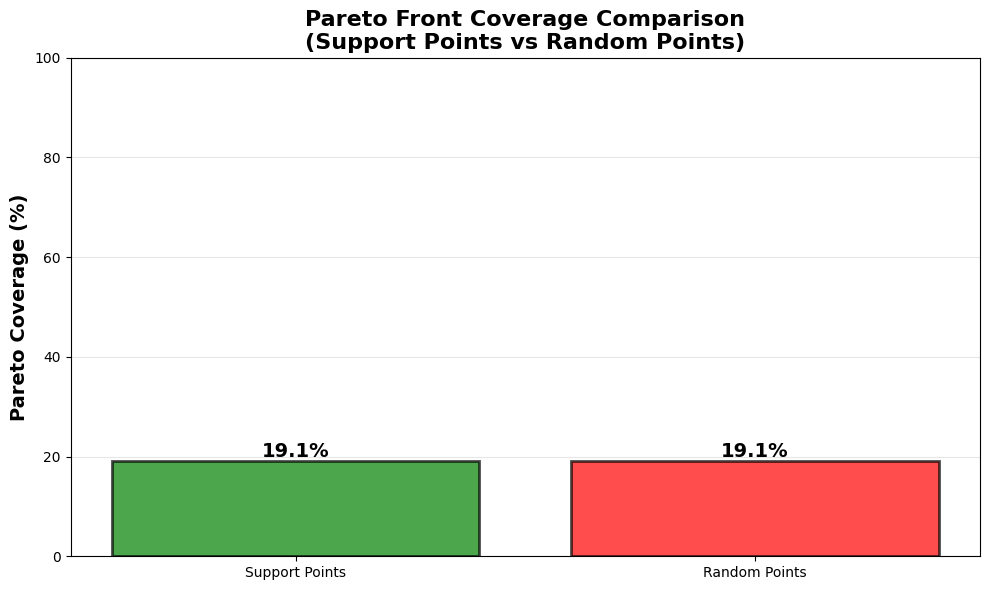

✓ Saved comparison_hypervolume.png


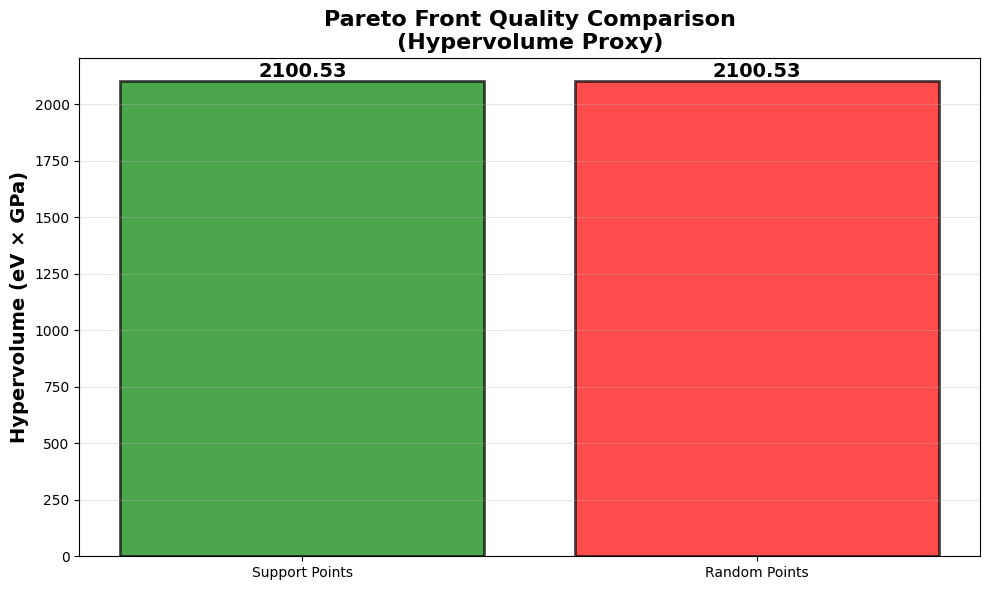

✓ Saved comparison_pareto_fronts.png


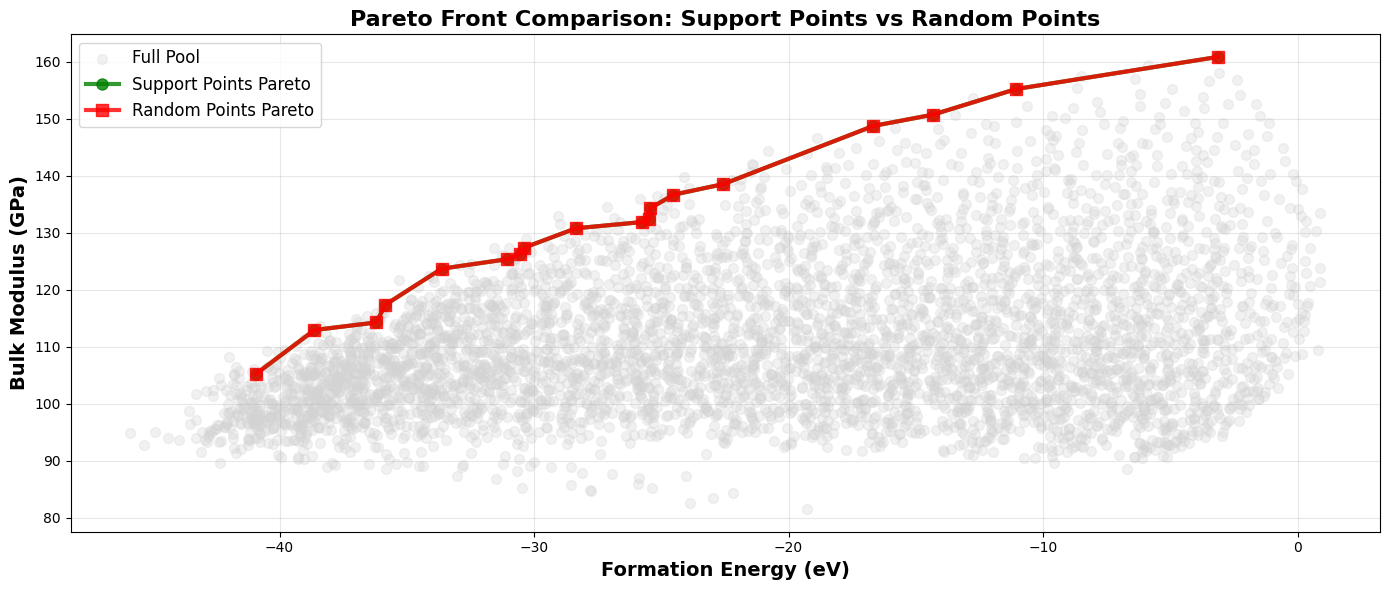


✓ All comparison plots saved!

COMPUTING ITERATIVE METRICS
True Pareto front size: 47
✓ Computed iterative metrics for both designs
✓ Saved iterative_pareto_coverage.png


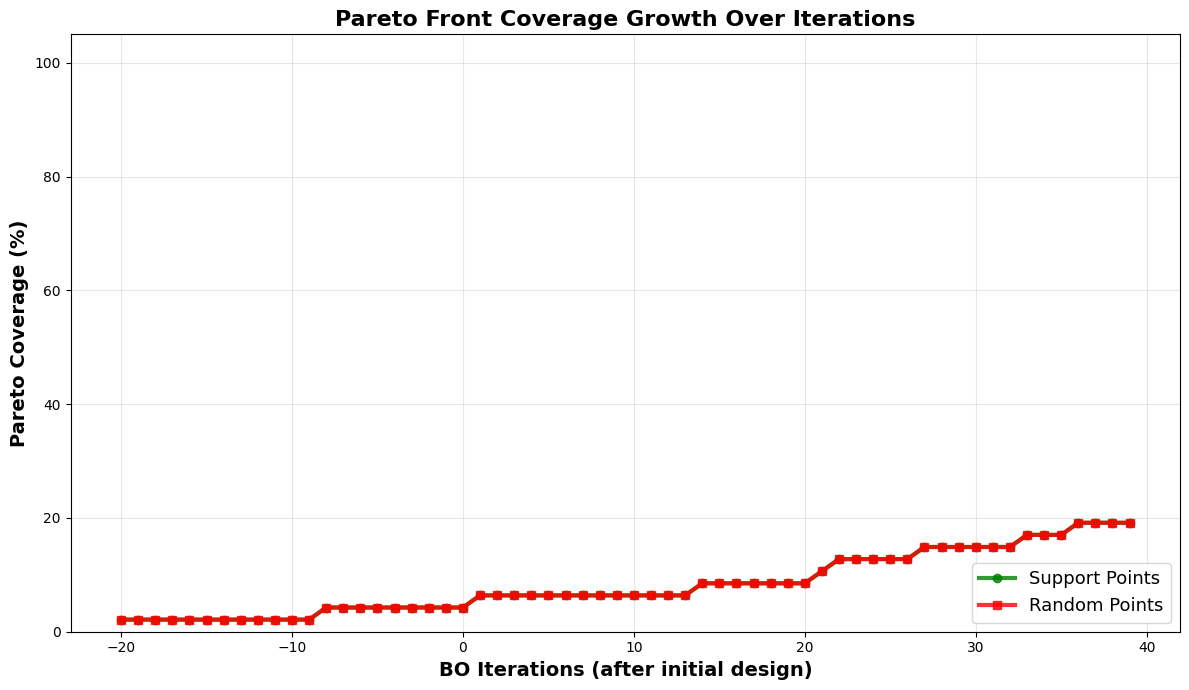

✓ Saved iterative_hypervolume.png


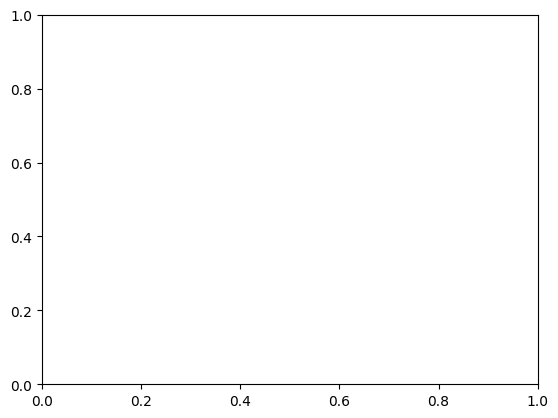

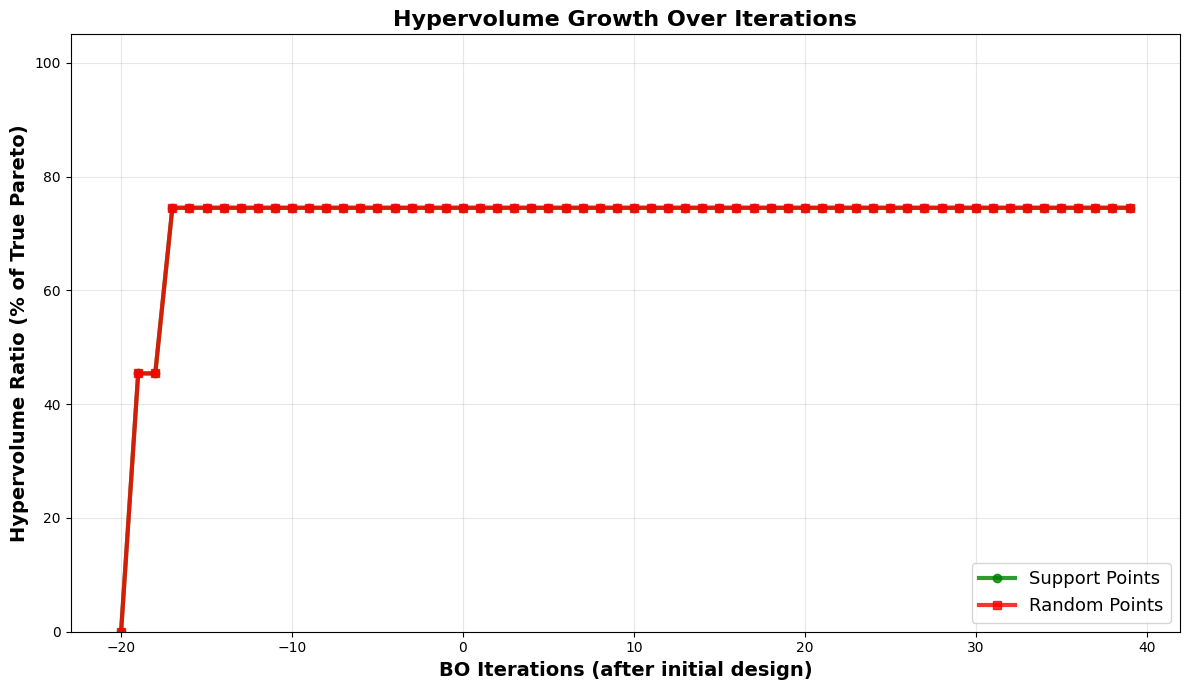


✓ All iterative analysis plots saved!


In [ ]:
# ============================================================================
# COMPARISON: SUPPORT POINTS vs RANDOM POINTS
# ============================================================================

print("\n" + "="*80)
print("LOADING COMPARISON DATA")
print("="*80)

# Load results from both designs
support_results = pd.read_csv(os.path.join(HOME, "Analyze4RHEA", "pareto_results_support_points.csv"))
random_results = pd.read_csv(os.path.join(HOME, "Analyze4RHEA", "pareto_results_random_points.csv"))

print(f"✓ Loaded support_points results: {len(support_results)} evaluations")
print(f"✓ Loaded random_points results: {len(random_results)} evaluations")

# Compute Pareto fronts for comparison
def compute_pareto_metrics(results_df):
    """Compute Pareto front and coverage metrics"""
    energy = results_df['Formation_Energy_eV'].values
    moduli = results_df['Bulk_Modulus_GPa'].values

    # Current Pareto front
    y_current = torch.stack(
        [torch.tensor(-energy), torch.tensor(moduli)],
        dim=1
    )
    pareto_mask = is_non_dominated(y_current).cpu().numpy()

    pareto_energies = energy[pareto_mask]
    pareto_moduli = moduli[pareto_mask]

    # Hypervolume
    hv = (pareto_energies.max() - pareto_energies.min()) * (pareto_moduli.max() - pareto_moduli.min())

    return {
        'pareto_energies': pareto_energies,
        'pareto_moduli': pareto_moduli,
        'pareto_size': pareto_mask.sum(),
        'hypervolume': hv,
        'n_evals': len(results_df)
    }

support_metrics = compute_pareto_metrics(support_results)
random_metrics = compute_pareto_metrics(random_results)

print("\n" + "="*80)
print("COMPARISON RESULTS")
print("="*80)
print(f"\nSupport Points:")
print(f"  Pareto size: {support_metrics['pareto_size']}")
print(f"  Hypervolume: {support_metrics['hypervolume']:.2f}")
print(f"  Total evals: {support_metrics['n_evals']}")

print(f"\nRandom Points:")
print(f"  Pareto size: {random_metrics['pareto_size']}")
print(f"  Hypervolume: {random_metrics['hypervolume']:.2f}")
print(f"  Total evals: {random_metrics['n_evals']}")

# Compute coverage for each
def compute_coverage(results_df, method_name):
    """Compute Pareto coverage vs true pool"""
    energy = results_df['Formation_Energy_eV'].values
    moduli = results_df['Bulk_Modulus_GPa'].values

    # True Pareto front
    y_pool = torch.stack([-energy_pool_tensor, moduli_pool_tensor], dim=1)
    pool_pareto_mask = is_non_dominated(y_pool).cpu().numpy()
    true_pareto_energies = energy_pool[pool_pareto_mask]

    true_pareto_moduli = moduli_pool[pool_pareto_mask]

    # BO Pareto
    y_bo = torch.stack([-torch.tensor(energy), torch.tensor(moduli)], dim=1)
    bo_pareto_mask = is_non_dominated(y_bo).cpu().numpy()
    bo_pareto_energies = energy[bo_pareto_mask]
    bo_pareto_moduli = moduli[bo_pareto_mask]

    # Coverage
    tolerance = 0.1
    coverage_count = 0
    for te, tm in zip(true_pareto_energies, true_pareto_moduli):
        match = np.any((np.abs(bo_pareto_energies - te) < tolerance) &
                       (np.abs(bo_pareto_moduli - tm) < tolerance))
        if match:
            coverage_count += 1

    coverage_pct = (coverage_count / len(true_pareto_energies)) * 100 if len(true_pareto_energies) > 0 else 0

    return coverage_pct, len(true_pareto_energies)

support_coverage, true_size = compute_coverage(support_results, "support_points")
random_coverage, _ = compute_coverage(random_results, "random_points")

print(f"\nPareto Coverage (True Front: {true_size} points):")
print(f"  Support Points: {support_coverage:.1f}%")
print(f"  Random Points:  {random_coverage:.1f}%")

# ============================================================================
# COMPARISON PLOTS
# ============================================================================

print("\n" + "="*80)
print("GENERATING COMPARISON PLOTS")
print("="*80)

# Plot 1: Pareto Coverage Comparison
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Support Points', 'Random Points']
coverage = [support_coverage, random_coverage]
colors = ['green', 'red']

bars = ax.bar(methods, coverage, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, coverage):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Pareto Coverage (%)', fontsize=14, fontweight='bold')
ax.set_title('Pareto Front Coverage Comparison\n(Support Points vs Random Points)',
             fontsize=16, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(HOME, "Analyze4RHEA", 'comparison_pareto_coverage.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved comparison_pareto_coverage.png")
plt.show()
plt.close()

# Plot 2: Hypervolume Comparison
fig, ax = plt.subplots(figsize=(10, 6))

hv_values = [support_metrics['hypervolume'], random_metrics['hypervolume']]

bars = ax.bar(methods, hv_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, val in zip(bars, hv_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Hypervolume (eV × GPa)', fontsize=14, fontweight='bold')
ax.set_title('Pareto Front Quality Comparison\n(Hypervolume Proxy)',
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(HOME, "Analyze4RHEA", 'comparison_hypervolume.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved comparison_hypervolume.png")
plt.show()
plt.close()

# Plot 3: Side-by-side Pareto fronts
fig, ax = plt.subplots(figsize=(14, 6))

# Plot both Pareto fronts
sort_idx_support = np.argsort(support_metrics['pareto_energies'])
sort_idx_random = np.argsort(random_metrics['pareto_energies'])

ax.scatter(energy_pool, moduli_pool, s=50, color='lightgray', alpha=0.3, label='Full Pool')

ax.plot(support_metrics['pareto_energies'][sort_idx_support],
        support_metrics['pareto_moduli'][sort_idx_support],
        'o-', color='green', linewidth=3, markersize=8, label='Support Points Pareto', alpha=0.8)

ax.plot(random_metrics['pareto_energies'][sort_idx_random],
        random_metrics['pareto_moduli'][sort_idx_random],
        's-', color='red', linewidth=3, markersize=8, label='Random Points Pareto', alpha=0.8)

ax.set_xlabel('Formation Energy (eV)', fontsize=14, fontweight='bold')
ax.set_ylabel('Bulk Modulus (GPa)', fontsize=14, fontweight='bold')
ax.set_title('Pareto Front Comparison: Support Points vs Random Points',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(HOME, "Analyze4RHEA", 'comparison_pareto_fronts.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved comparison_pareto_fronts.png")
plt.show()
plt.close()

print("\n✓ All comparison plots saved!")


# ============================================================================
# ITERATIVE METRICS TRACKING (HV and Pareto Coverage Over Iterations)
# ============================================================================

print("\n" + "="*80)
print("COMPUTING ITERATIVE METRICS")
print("="*80)

def compute_iterative_metrics(results_df, initial_size, true_pareto_energies, true_pareto_moduli):
    """Compute HV and coverage at each iteration"""

    hv_history = []
    coverage_history = []
    iteration_counts = []

    # True Pareto stats
    true_hv = (true_pareto_energies.max() - true_pareto_energies.min()) * \
              (true_pareto_moduli.max() - true_pareto_moduli.min())

    # Iterate through evaluation counts
    for eval_num in sorted(results_df['DFT_Eval_Count'].unique()):
        subset_df = results_df[results_df['DFT_Eval_Count'] <= eval_num]

        # Compute Pareto front at this point
        energy = subset_df['Formation_Energy_eV'].values
        moduli = subset_df['Bulk_Modulus_GPa'].values

        y_subset = torch.stack(
            [torch.tensor(-energy), torch.tensor(moduli)],
            dim=1
        )
        pareto_mask = is_non_dominated(y_subset).cpu().numpy()

        pareto_energies = energy[pareto_mask]
        pareto_moduli = moduli[pareto_mask]

        # HV
        if len(pareto_energies) > 1:
            hv = (pareto_energies.max() - pareto_energies.min()) * \
                 (pareto_moduli.max() - pareto_moduli.min())
            hv_ratio = (hv / true_hv) * 100
        else:
            hv_ratio = 0

        # Coverage
        tolerance = 0.1
        coverage_count = 0
        for te, tm in zip(true_pareto_energies, true_pareto_moduli):
            match = np.any((np.abs(pareto_energies - te) < tolerance) &
                          (np.abs(pareto_moduli - tm) < tolerance))
            if match:
                coverage_count += 1

        coverage_pct = (coverage_count / len(true_pareto_energies)) * 100

        hv_history.append(hv_ratio)
        coverage_history.append(coverage_pct)
        iteration_counts.append(eval_num - initial_size)

    return iteration_counts, hv_history, coverage_history

# Compute true Pareto front (ground truth)
y_pool = torch.stack([-energy_pool_tensor, moduli_pool_tensor], dim=1)
pool_pareto_mask = is_non_dominated(y_pool).cpu().numpy()
true_pareto_energies = energy_pool[pool_pareto_mask]
true_pareto_moduli = moduli_pool[pool_pareto_mask]

print(f"True Pareto front size: {len(true_pareto_energies)}")

# Compute metrics for both designs
support_iters, support_hv, support_coverage = compute_iterative_metrics(
    support_results, len(initial_data), true_pareto_energies, true_pareto_moduli
)
random_iters, random_hv, random_coverage = compute_iterative_metrics(
    random_results, len(initial_data), true_pareto_energies, true_pareto_moduli
)

print(f"✓ Computed iterative metrics for both designs")

# ============================================================================
# PLOT: PARETO COVERAGE OVER ITERATIONS
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(support_iters, support_coverage, 'o-', color='green', linewidth=3,
        markersize=6, label='Support Points', alpha=0.8)
ax.plot(random_iters, random_coverage, 's-', color='red', linewidth=3,
        markersize=6, label='Random Points', alpha=0.8)

ax.set_xlabel('BO Iterations (after initial design)', fontsize=14, fontweight='bold')
ax.set_ylabel('Pareto Coverage (%)', fontsize=14, fontweight='bold')
ax.set_title('Pareto Front Coverage Growth Over Iterations', fontsize=16, fontweight='bold')
ax.legend(fontsize=13, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(HOME, "Analyze4RHEA", 'iterative_pareto_coverage.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved iterative_pareto_coverage.png")
plt.show()
plt.close()
plt.cla()

# ============================================================================
# PLOT: HYPERVOLUME RATIO OVER ITERATIONS
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(support_iters, support_hv, 'o-', color='green', linewidth=3,
        markersize=6, label='Support Points', alpha=0.8)
ax.plot(random_iters, random_hv, 's-', color='red', linewidth=3,
        markersize=6, label='Random Points', alpha=0.8)

ax.set_xlabel('BO Iterations (after initial design)', fontsize=14, fontweight='bold')
ax.set_ylabel('Hypervolume Ratio (% of True Pareto)', fontsize=14, fontweight='bold')
ax.set_title('Hypervolume Growth Over Iterations', fontsize=16, fontweight='bold')
ax.legend(fontsize=13, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(HOME, "Analyze4RHEA", 'iterative_hypervolume.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved iterative_hypervolume.png")
plt.show()
plt.close()

print("\n✓ All iterative analysis plots saved!")
